# **역함수**

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

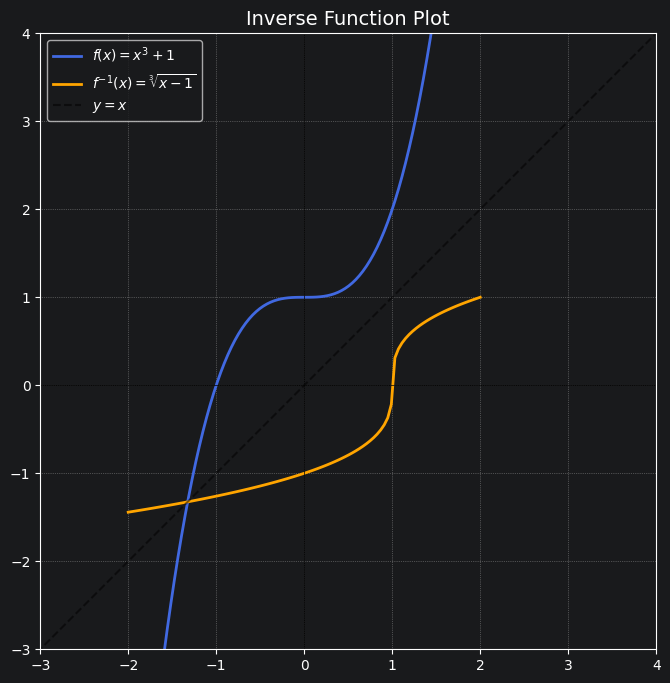

In [8]:
# 1. 함수 정의
def f(x):
    return x**3 + 1

# 2. 역함수 계산 함수
def f_inv(y_value):
    # 초기값을 y_value의 세제곱근 정도로 주면 fsolve가 더 잘 찾는다.
    initial_guess = np.sign(y_value) * np.abs(y_value)**(1/3)
    #np.sign은 부호를 판별해주는 기능을 한다.

    # xtol 옵션을 추가해 계산 정밀도를 조절할 수 있다.
    result = fsolve(lambda x: f(x) - y_value, initial_guess, xtol=1.49012e-08)
    return result[0]

f_inv_vec = np.vectorize(f_inv)

x = np.linspace(-2, 2, 100)
# np.linspace(start, stop, num) : 특정 구간을 일정한 간격으로 나누는 점을 생성하는 함수
y = f(x)
y_inv = f_inv_vec(x)

# 4. 시각화
plt.figure(figsize=(8, 8))

plt.plot(x, y, label=r'$f(x) = x^3 + 1$', color='royalblue', lw=2)
plt.plot(x, y_inv, label=r'$f^{-1}(x) = \sqrt[3]{x-1}$', color='orange', lw=2)
plt.plot([-5, 5], [-5, 5], 'k--', alpha=0.5, label=r'$y = x$')

plt.xlim(-3, 4)
plt.ylim(-3, 4)
plt.axhline(0, color='black', lw=0.5)
plt.axvline(0, color='black', lw=0.5)
plt.grid(True, linestyle=':', alpha=0.7)
plt.gca().set_aspect('equal')
plt.title("Inverse Function Plot", fontsize=14)
plt.legend()
plt.show()
